# SPICE-posed synthetic lunar satellite imagery

Generate two candidate images that could stand in for real spacecraft imagery in
terrain-relative navigation (TRN) testing, for a real LROC WAC image selected ahead of time (see
`dataset_manifest.csv` below): a synthetic 256x256 render from real Lunaserv WMS DEM/imagery via
NASA's Ames Stereo Pipeline `sat_sim` (Phase 5), and the same real footprint's actual WAC image
processed through ISIS3's own EDR-to-calibrated-cube pipeline (`isis_wac.py`, Phase 6). Both are
posed using the **real LRO spacecraft trajectory** (NAIF SPICE kernels) at the timestamp of that
real image. Validates each candidate's geometry against a common reference -- a real
hillshade-based basemap -- two ways: a raw, north-up-rotated quality check, and a true
pixel-for-pixel geo-registered overlay (the synthetic render via a CSM camera model and ASP's
`mapproject`; the real WAC crop via ISIS's own native Pushframe camera model and `cam2map`,
after `mapproject`'s CSM route turned out to have a real geometric bug for this sensor type --
see Phase 6's notes). Phase 7 then compares the two candidates directly against each other, with
explicit tie points, and Phase 8 validates a third candidate -- `reproject`, the same synthetic
camera as Phase 5 but textured from the real WAC crop's own reflectance -- the same two ways.
See `../docs/plan.md` for the full phase-by-phase approach,
`../docs/dataset-plan.md` for the `TrnTestDataSet`/`TrnTestEntry`/`TrnTestImage` object model
Phases 2-6B are built on, and `../docs/data-sources.md` for the researched specifics referenced
below.

This notebook drives the installed `trntest` package (see `../src/trntest/`) rather than
duplicating its logic -- each cell is close to a one-line call into the package.

**Which image**: this notebook reads `dataset_manifest.csv`, a small file checked into this
repo alongside this notebook -- a frozen, real catalog-driven selection result (the notebook that
used to regenerate it, `data_set_selection.ipynb`, was later removed once nothing else depended
on re-running it; see `../docs/history.md`'s dated entry). To render a different real image,
either hand-edit this CSV or produce a new one via `dataset.images_for_window`/`dataset_selection.
resolve_orbit_sequence` and `trntest.write_manifest`.

In [1]:
import dataclasses
import json

import trntest
from trntest import craters, plotting, tie_points

images = trntest.read_manifest("dataset_manifest.csv")
print(f"Rendering EDR product: {images.iloc[0]['edr_product']} (from dataset_manifest.csv)")

session = trntest.Session()

Rendering EDR product: M1327210646CE (from dataset_manifest.csv)


## Phase 2: generate the selected image + SPICE-derived camera pose

`trntest.TrnTestDataSet.create(...)` sets up (or reuses) a self-contained dataset folder for
the *whole* manifest above -- see `../docs/dataset-plan.md` for the full design. This notebook
always wants a fresh render of the manifest's first entry reflecting whatever pipeline code is
currently checked out (not a silently-reused prior run, which would be actively misleading while
iterating on `render.py`/`isis_wac.py`), so `dataset.truncate(dataset[0])` first deletes that
entry's already-generated `crop`/`hillshade` product files (if any) and resets its task-queue
state back to `pending` -- then `dataset.populate(limit=1)` drives the task queue to (re)generate
it: a pinhole camera posed from LRO's real position/orientation (NAIF SPICE kernels, `MOON_ME`
frame) at that row's timestamp, the DEM/ortho fetch, and both the `sat_sim` render and the real,
ISIS-processed WAC crop. `populate(limit=1)` stops once it's done genuinely new work on 1 entry
-- since `truncate()` just reset entry 0 specifically to `pending`, and entries are processed in
manifest order starting from 0, this always lands on entry 0, never spilling into other manifest
rows regardless of their own state (see `../docs/dataset-plan.md`'s "Task queue" section for why
`limit` counts new work done, not manifest position, and why that distinction matters here).
`truncate()` leaves `_work/<edr_product>/`'s DEM/ortho intermediates alone, so this doesn't
re-fetch those from Lunaserv/Astropedia every run, just re-renders from them.

In [2]:
PRODUCT_TYPES = ("crop", "hillshade", "reproject")  # "reproject" is opt-in (trn_dataset.PRODUCT_TYPES
# defaults to just crop+hillshade) -- included explicitly here so Phase 8 below has it to work with.

dataset = trntest.TrnTestDataSet.create(session.config.output_dir / "trn_dataset", images, session.config)
dataset.truncate(dataset[0], product_types=PRODUCT_TYPES)
dataset.populate(limit=1, product_types=PRODUCT_TYPES)
entry = dataset[0]

camera = entry.camera
frame_timing = entry.frame_timing
session = trntest.Session(config=entry.per_image_config)

print(json.dumps(dataclasses.asdict(camera), indent=2, default=str))

{
  "et": 625843629.6404576,
  "center_frame_index": 129.0,
  "camera_center_moon_me_m": [
    -1436043.1493582418,
    265174.67205154215,
    1154372.7412624918
  ],
  "camera_along_track_direction_moon_me": [
    0.5055513562757797,
    -0.17620690348422366,
    0.8446117174964015
  ],
  "r_cam_to_me": [
    [
      0.22952225464154483,
      0.5055513562757797,
      0.8317074971358509
    ],
    [
      0.9711160733107735,
      -0.1762069034842235,
      -0.16088722547786674
    ],
    [
      0.06521584762713922,
      0.8446117174964015,
      -0.5313924537345752
    ]
  ],
  "boresight_rotation_k": 3,
  "slant_range_km": 124.8742959901997,
  "off_nadir_deg": 6.239135360774561,
  "focal_length_u_px": 249.57196058556903,
  "focal_length_v_px": 249.57196058556903,
  "principal_point_u_px": 128.0,
  "principal_point_v_px": 133.7088797895497,
  "footprint_lonlat_deg": {
    "center": [
      169.57576859858,
      38.772670465555
    ],
    "top_left": [
      171.8655332173884,
  

Sanity check: altitude and sub-spacecraft location should be consistent with LRO's known Fourth Extended Science Mission frozen elliptical orbit (low periapsis over the south pole).

In [3]:
print(f"Slant range to surface: {camera.slant_range_km:.2f} km")
print(f"Off-nadir angle: {camera.off_nadir_deg:.2f} deg")
print(f"Ground footprint center (lon, lat): {camera.footprint_lonlat_deg['center']}")

Slant range to surface: 124.87 km
Off-nadir angle: 6.24 deg
Ground footprint center (lon, lat): (np.float64(169.57576859858), np.float64(38.772670465555))


## Phase 3: DEM + ortho from Lunaserv WMS

Fetch `luna_wac_normalized_reflectance` (visible mosaic, despeckled and blended with a real-sun-lit hillshade -- see `docs/data-sources.md`) and `luna_wac_dtm_numeric_meters_absolute` (GLD100 DEM, converted from planetocentric radius to elevation) for the footprint above, through the local cache. Displayed with the SPICE-derived camera's ground footprint (corners + center) overlaid on the ortho, to visually confirm the pose lands where expected.

That hillshade is a real Hapke bidirectional reflectance function by default (ISIS `photomet`, using the camera's own real position for true per-pixel emission/phase -- `lunaserv.hapke_shade_ortho`), not just a plain Lambertian blend, with a further along-track correction also on by default (`along_track_correction`, approximating this project's single-frozen-camera-pose limitation for a real multi-second pushframe scan using the camera's own along-track attitude axis) -- see `notebooks/hapke_hillshade.ipynb` and `notebooks/along_track_correction.ipynb` for direct comparisons against each fallback (`hapke=False`, `along_track_correction=False`) and `docs/history.md`'s dated entries for both evaluations.

In [4]:
dem_ortho_result = entry.dem_ortho_result
print(json.dumps(dataclasses.asdict(dem_ortho_result), indent=2, default=str))

{
  "ortho": "/workspace/output/trn_dataset/_work/M1327210646CE/ortho_shaded_hapke_atc.tif",
  "dem": "/workspace/output/trn_dataset/_work/M1327210646CE/dem_filled-tile-0.tif",
  "bbox": [
    -126222.027845,
    -126552.58747700002,
    138258.13878399998,
    139801.459907
  ],
  "width": 2645,
  "height": 2664
}


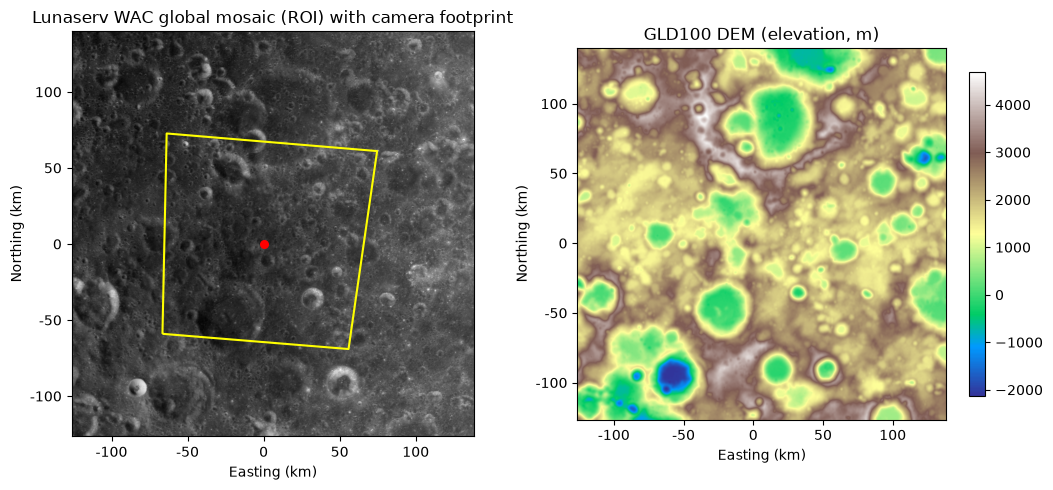

In [5]:
_ = plotting.plot_dem_ortho(dem_ortho_result, camera)

## Phase 4: render with `sat_sim` + the real camera pose

`dataset.populate()` already generated `entry.hillshade` above -- `TrnTestHillshadeImage._generate_impl`
calls `render.run_sat_sim(camera, dem_ortho_result)`, which:
1. Calls `sat_sim --camera-list` with the Phase 2 `.tsai` camera against the Phase 3 DEM/ortho, producing the synthetic 256x256 image.
2. Calls ASP's `cam_gen` to convert that exact camera to a CSM Frame model-state JSON (the "ISD" sidecar) -- `--save-as-csm` is a no-op in `--camera-list` mode, see `docs/data-sources.md`.

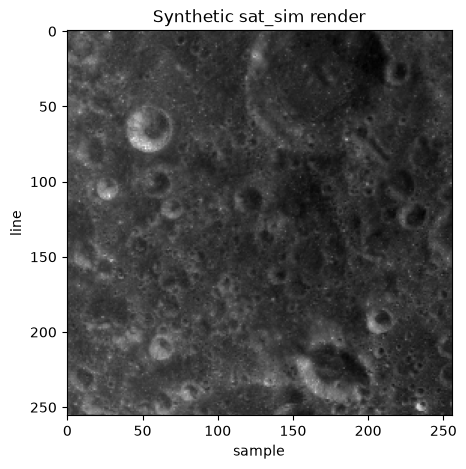

In [6]:
_ = plotting.plot_synthetic_render(entry.hillshade.raster_path)

### The CSM / "ISD" JSON sidecar

The state file's first line is a bare model-name string (not JSON) -- standard CSM "state string" convention; skip it before parsing.

In [7]:
model_name, csm_state = trntest.read_csm_state(entry.hillshade.sidecar_json_path)

print("Model name:", model_name)
for key in ["m_focalLength", "m_nLines", "m_nSamples", "m_ccdCenter", "m_currentParameterValue"]:
    print(f"{key}: {csm_state[key]}")

Model name: USGS_ASTRO_FRAME_SENSOR_MODEL
m_focalLength: 249.57196058556903
m_nLines: 256
m_nSamples: 256
m_ccdCenter: [133.7088797895497, 128.0]
m_currentParameterValue: [-1436043.149392321, 265174.67202917684, 1154372.7413072637, 0.6959025815588102, 0.5304864031411757, 0.32221584191799907, 0.36122115702045593]


`m_currentParameterValue`'s first 3 entries are the camera center (X, Y, Z, meters, MOON_ME frame) and the last 4 are the orientation quaternion -- matching the `C`/`R` we computed from SPICE in Phase 2.

### North-up rotation (display only)

The sensor model's own pixel axes are a **fixed, hardware-motivated** choice -- not something that should vary by pass (see `camera.boresight_rotation_k`'s docstring and `docs/data-sources.md`'s "Pass-dependent sensor axis convention") -- but *which way is north* in that fixed convention depends on this specific pass (ascending vs. descending, plus any yaw state), so it's computed here purely for display, and reused throughout Phases 5-7 below. `trntest.orientation` picks, for each image independently, the multiple of 90 degrees (no mirroring) whose on-screen "up" is closest to true north, and this is applied only to the plotted arrays below -- the `.tsai`, the CSM/ISD JSON, and any pixel coordinates computed elsewhere are untouched.

Since the synthetic render and the real WAC crop already share the same fixed axis convention, we expect -- and confirm below -- that they need the *same* rotation here.

In [8]:
rotations = entry.rotations
print(
    f"synthetic: rotate {rotations.k_synthetic * 90} deg for north-up (residual {rotations.dev_synthetic_deg:.1f} deg from true north)"
)
print(
    f"real crop: rotate {rotations.k_crop * 90} deg for north-up (residual {rotations.dev_crop_deg:.1f} deg from true north)"
)

synthetic: rotate 180 deg for north-up (residual 8.2 deg from true north)
real crop: rotate 0 deg for north-up (residual 4.5 deg from true north)


### Tie points (display only)

`session.select_tie_points()` finds the real ground area both the synthetic render and the real WAC crop cover (each image's own footprint, an inscribed axis-aligned lon/lat box per image, intersected -- an approximate estimate, used only to pick plausible candidate points, not to place them), picks 5 points in a die's "5"/X pattern (4 corners + center, 10% margin from the shared area's edges), and projects each into the synthetic image's exact pixel coordinates (closed-form pinhole, the same fixed pose that rendered it). The real WAC crop's own pixel coordinates (`crop_px`) aren't resolved here yet -- that needs the real crop cube to exist first (Phase 6, below), and now goes through a genuine ISIS `campt` ground-to-image query against it, not a hand-rolled approximation (see `tie_points.py`'s module docstring). Reused throughout Phases 5-7 below: on the render panels of 5A/6A (marking the same 5 real ground points on each candidate's own raw image), and for the direct comparison in Phase 7.

In [9]:
tie_point_results = session.select_tie_points(camera, frame_timing)
for name, r in tie_point_results.items():
    print(f"{name:12s} lonlat={r['lonlat']}  synthetic_px={r['synthetic_px']}")

top_left     lonlat=(167.55827388148018, 40.43343630153574)  synthetic_px=(np.float64(223.78087017197848), np.float64(221.54326016561868))
top_right    lonlat=(171.83919257609367, 40.4290547889409)  synthetic_px=(np.float64(37.96056357090298), np.float64(236.09700649940027))
center       lonlat=(169.57576859858, 38.772670465555)  synthetic_px=(np.float64(128.0), np.float64(133.70887978954968))
bottom_left  lonlat=(167.64885994081783, 37.16221639112466)  synthetic_px=(np.float64(216.09602734606085), np.float64(26.130435893260355))
bottom_right lonlat=(171.73757526475094, 37.15803168738062)  synthetic_px=(np.float64(12.540519490276921), np.float64(43.57140457903381))


## Phase 5: does the synthetic render's geometry check out?

This demo's actual goal is generating synthetic images that could stand in for real spacecraft imagery in terrain-relative navigation (TRN) testing -- so the real question for each candidate TRN test image (the synthetic render here; the real, ISIS-processed WAC crop in Phase 6) is whether its geometry genuinely matches reality, not just whether it looks plausible. Both phases check this two ways against the same reference -- the hillshade-based ortho basemap (`dem_ortho_result.ortho`), Phase 3's own best available geometry reference:

- **A: raw image quality.** The render's own unprojected pixels, rotated north-up and scaled to real km, next to a plain crop of the basemap covering the same real footprint, both marked with the same 5 tie points -- a quick, ad hoc look at whether the render's content and rough position/scale make sense (`plotting.plot_render_vs_basemap`).
- **B: pixel-for-pixel alignment.** The render reprojected onto the map through its own real camera model (`mapproject`) and overlaid directly on the basemap -- true geo-registration, not just visual similarity, as an auto-blinking animated GIF that alternates the overlay against the basemap (`plotting.plot_overlay_toggle`).

(Phase 7, below, is just 5A's and 6A's own render panels put together directly, for an easier side-by-side look at the two candidates themselves.)

Both 5B and 6B below also draw the Robbins et al. (2019) lunar crater database (`craters.crater_overlay_layer`) as an extra vector layer on top of the mapprojected overlay -- real catalog craters (ellipse-fit position/size, D>=1km) inside this image's own footprint, as a visual geometry cross-check: if the ellipses land on the actual crater rims visible in the hillshade basemap, that's independent confirmation the overlay's geo-registration is correct. (The ellipses' *orientation* specifically hasn't been visually confirmed before now -- see `craters._ellipse_polygon`'s docstring -- so this is also that check.) Computed once here since 5B and 6B share the same base raster (`dem_ortho_result.ortho`) and therefore the same query AOI/CRS; `crater_overlay_layer` returns `None` if no craters fall in view, so `crater_layers` is left `None` (no extra layer) rather than an empty list in that case.

`min_major_km=9.0`/`min_arc_img=0.75` together select ~80 craters, favoring rim quality within that size band rather than size alone -- `ARC_IMG` (fraction of each crater's rim actually traceable/used in its ellipse fit) is this database's only real proxy for a "grade"/sharpness field, and it's confounded with size (see `crater_overlay_layer`'s docstring: complex/degraded large craters have systematically lower `ARC_IMG` than trivially-traced small ones), so it's only meaningful as a filter *within* a size band like this, not applied to the whole database. (`min_arc_img` started at 0.86, ~40 craters -- relaxed to 0.75 since a stricter quality bar leaned toward smaller craters within the size band, which read as less visually prominent than the original size-only 40 despite being the same count.) Fading the outline itself (lower `alpha`/`linewidth`) turned out to make alignment *harder* to judge, not easier -- a faint line is hard to place precisely against the rim. `linestyle=(0, (1, 6))` (a sparse dashed line, `OverlayLayer`'s own style field) instead keeps the dashes at full width/a light, warm `color` (`#ffddbb`, higher contrast against the mostly-dark basemap than the original orange) but leaves most of the underlying rim visible between them, so each dash is a precise, high-contrast check of whether the ellipse boundary is sitting on the real rim at that point.

In [10]:
# matplotlib dash-tuple format: (phase_offset, (dash_pt, gap_pt, ...)) -- phase_offset shifts where
# the pattern starts, only useful for aligning multiple dashed lines' phases; 0 (unshifted) is the
# standard case and what's used here.
dash_phase_offset = 0
crater_layer = craters.crater_overlay_layer(
    dem_ortho_result.ortho,
    entry.per_image_config,
    min_major_km=9.0,
    min_arc_img=0.75,
    color="#ffddbb",
    linewidth=2.0,
    linestyle=(dash_phase_offset, (1, 6)),
)
crater_layers = [crater_layer] if crater_layer is not None else None
print(f"Robbins craters in view: {len(crater_layer.geoseries) if crater_layer is not None else 0}")

Robbins craters in view: 78


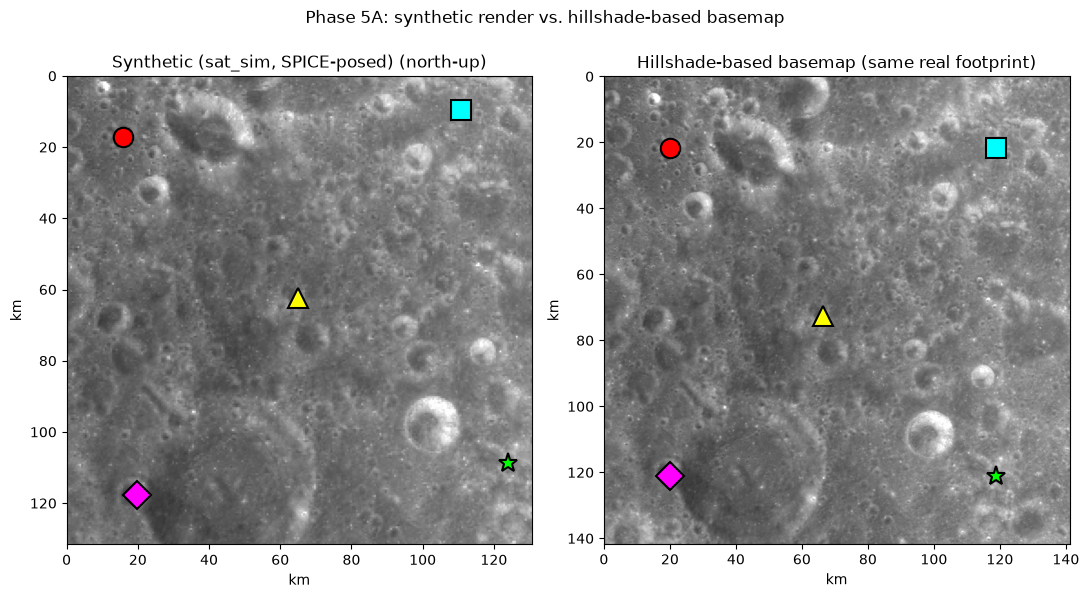

In [11]:
_ = entry.hillshade.plot_vs_basemap(
    tie_point_results=tie_point_results,
    title="Phase 5A: synthetic render vs. hillshade-based basemap",
)

`entry.hillshade.plot_overlay()` reprojects the synthetic render through the exact CSM/ISD sidecar `cam_gen` already produced for it (`render.run_mapproject_image`'s `--ref-map`) -- the geometric inverse of `sat_sim`'s own forward DEM+camera-to-image render, through that same camera model -- onto the same DEM the render came from, so the result shares an exact pixel grid with `dem_ortho_result.ortho` with no separate alignment step. Displays both with `rioxarray`, using each file's own real geographic coordinates rather than pixel indices, as an animated GIF that automatically blinks the overlay on and off.


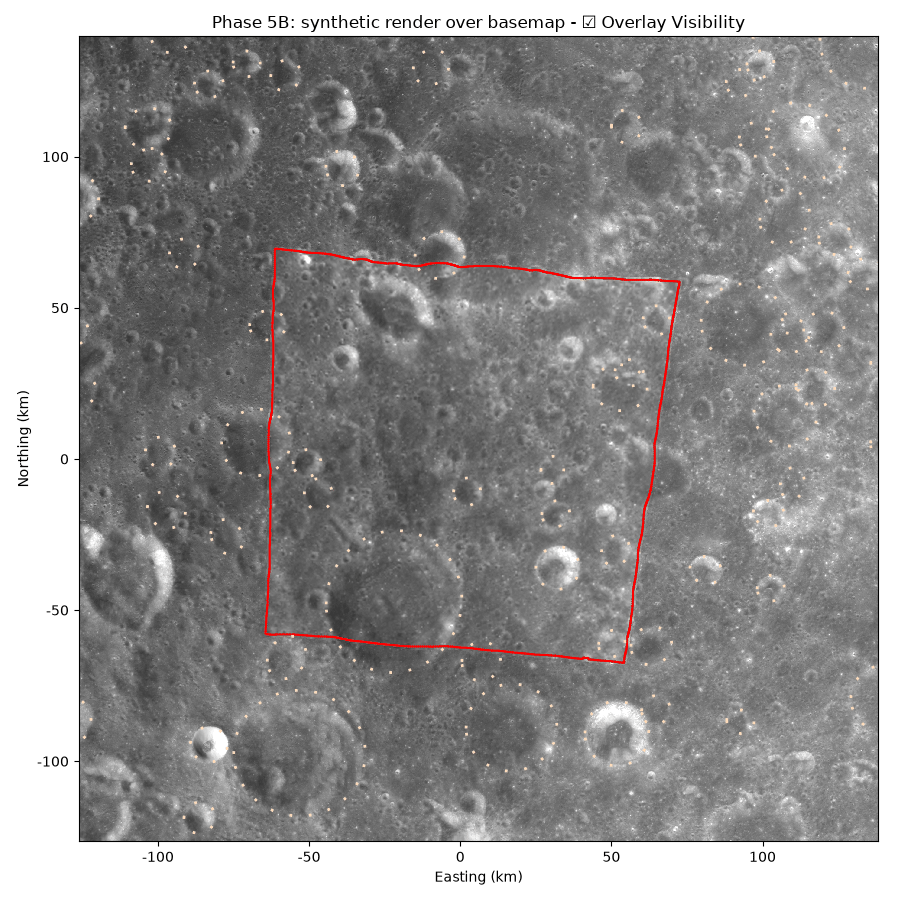

In [12]:
entry.hillshade.plot_overlay(title="Phase 5B: synthetic render over basemap", layers=crater_layers)

## Phase 6: does the real, ISIS-processed WAC crop's geometry check out?

The same two-style geometry check as Phase 5, for the other TRN test image candidate: a roughly square center crop of the product's real WAC EDR, processed through ISIS3's own pipeline instead of `sat_sim`. WAC is a push-frame camera: each 78-line frame multiplexes 7 filters (2 UV @ 4 TDI lines + 5 VIS @ 14 TDI lines), and getting a usable, calibrated image out of the raw EDR takes real processing. `dataset.populate()` (Phase 2) already generated `entry.crop` -- `TrnTestCropImage._generate_impl` steps the product's real EDR through ISIS3's own pipeline (`lrowac2isis` -> `spiceinit web=yes` -> `lrowaccal` -> `framestitch`, exposed as `entry.stitched`) -- calibrated, band-separated, and framelet-interleaved through a genuine camera-model-aware toolchain, not a hand-derived byte offset -- then crops it (`entry.crop_result`, via ISIS's own `crop` app) down to the real-footprint frame range (`camera.center_frame_index` +/- half of `camera.n_frames_for_square_crop`) -- a single, real "WAC crop" cube that both 6A (raw display, right below) and 6B (mapprojected, further below) derive from, the same way 5A/5B both already derive from one synthetic render with no special-casing.

Unlike 5B, 6B does *not* go through ASP's `mapproject` via a CSM/ISD sidecar. That path was tried extensively and abandoned: investigation traced its bad geometry to a real bug in `usgscsm`'s `UsgsAstroPushFrameSensorModel::groundToImage` (the function `mapproject` calls once per output pixel) -- an unbracketed secant search over framelet index that's unreliable for Pushframe images, badly so for a short crop. Confirmed independent of any ISD authoring choice (varying every plausible ISD field made no difference), confirmed via a chained-iteration round-trip test that never converges to a stable answer for the crop, and confirmed even the long-trusted *full-cube* reference used throughout this notebook's earlier validation is itself measurably affected (~0.2-0.4 correlation against ISIS's own native reprojection, despite the two using literally the same source pixels). `TrnTestCropImage.plot_overlay()` instead uses ISIS's own native camera model via `cam2map` (`isis_wac.run_cam2map_for_crop`) -- confirmed self-consistent regardless of crop size (crop vs. full cube agree to 0.9999986 correlation) and independently checked against `pyproj`'s own math to sub-micrometer precision. See `docs/history.md`'s dated entry for the full investigation.

`tie_points.resolve_crop_pixels()` queries each tie point's real pixel location in the real crop via `wac_camera_model.find_framelet_and_project` -- a from-scratch reimplementation of ISIS's own WAC-VIS camera model, validated to exact (0.000px) agreement with real ISIS `campt` output, replacing the deprecated SPICE-only approximation `select_tie_points` used to compute this same value with (see `tie_points.py`'s module docstring for the measured discrepancy this fixes). Used instead of a direct `campt` ground-to-image query (`isis_wac.ground_to_image_pixel`) because `campt`'s own solve has a real, scattered (~38% on this project's own default candidate) failure rate for WAC's Pushframe sensor -- a known upstream ISIS bug, not an edge-of-crop artifact (see `docs/wac-jigsaw-investigation.md`) -- that `find_framelet_and_project`'s own containment check sidesteps entirely. A die5 point still not covered by any real framelet (the approximate footprint used to pick candidate points can be off enough for this to happen for real, e.g. near the poles) is dropped with a printed warning rather than breaking the run.

In [13]:
tie_point_results = tie_points.resolve_crop_pixels(tie_point_results, entry.crop_result)
for name, r in tie_point_results.items():
    print(f"{name:12s} crop_px={r['crop_px']}")

top_left     crop_px=(np.float64(100.6979229157202), np.float64(187.1462879476153))
top_right    crop_px=(np.float64(592.2058918894477), np.float64(132.24749125241112))
center       crop_px=(np.float64(351.45519058073506), np.float64(492.34574400616214))
bottom_left  crop_px=(np.float64(134.36142195647653), np.float64(838.2411555827366))
bottom_right crop_px=(np.float64(626.8494473203948), np.float64(789.5293297033638))


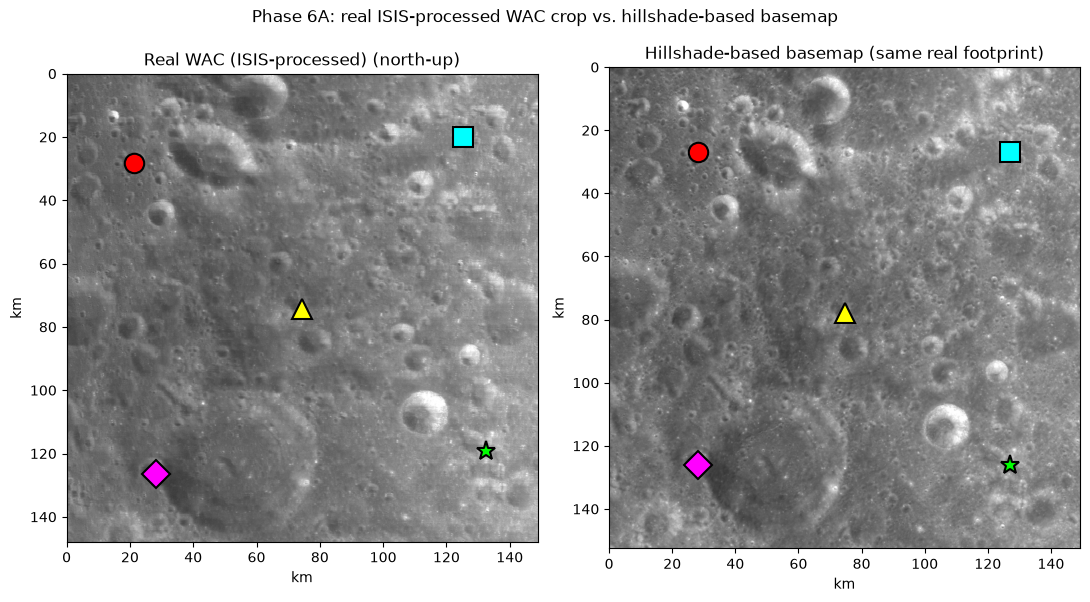

In [14]:
_ = entry.crop.plot_vs_basemap(
    tie_point_results=tie_point_results,
    title="Phase 6A: real ISIS-processed WAC crop vs. hillshade-based basemap",
)

`entry.crop.plot_overlay()` reprojects the real crop onto the map via ISIS's own native `cam2map` (`isis_wac.run_cam2map_for_crop`), using a map file cloned from `dem_ortho_result`'s own local Orthographic projection (`isis_wac._orthographic_map_pvl`) so the output lands in the same real-world coordinate system as `dem_ortho_result.ortho` -- the real-WAC counterpart to 5B's `mapproject`, sharing the same auto-blinking-GIF overlay display (no special-casing needed since the crop -- unlike the old full stitched cube -- already covers just the real footprint being compared).


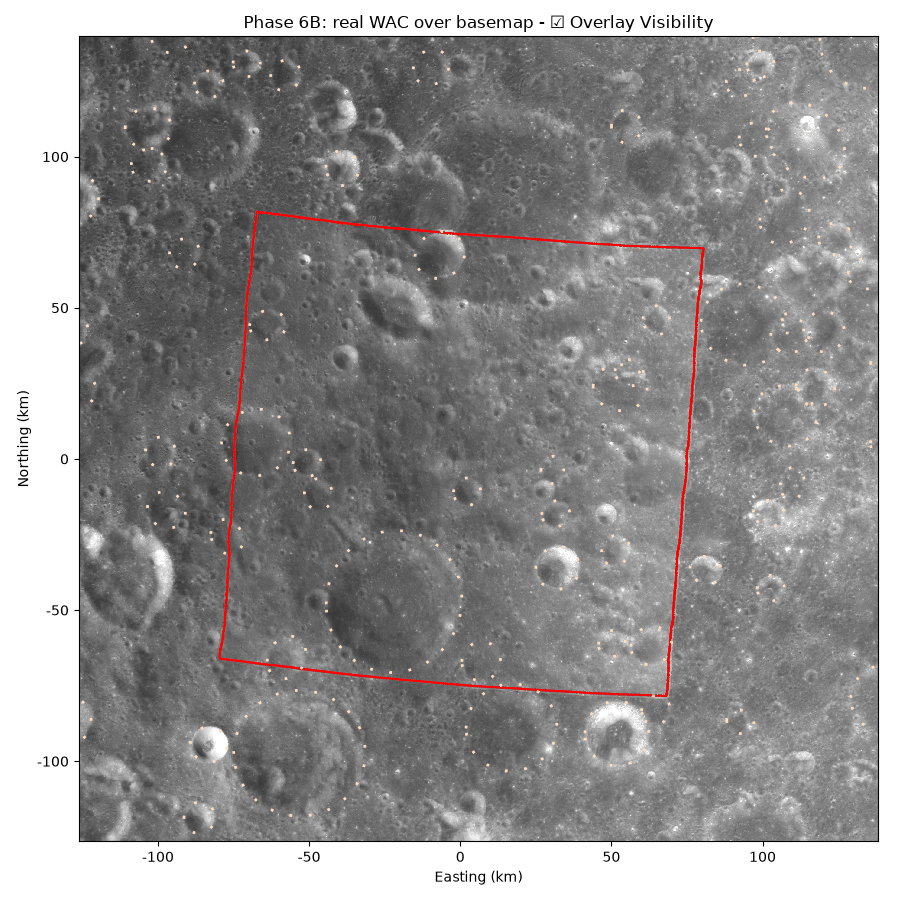

In [15]:
entry.crop.plot_overlay(title="Phase 6B: real WAC over basemap", layers=crater_layers)

## Phase 7: synthetic render vs. real WAC, side by side

Conceptually, just 5A's and 6A's own render panels (synthetic, real WAC crop -- same tie points, same north-up rotation, computed above) put together directly, for an easier side-by-side look at the two TRN test image candidates themselves, rather than each against the basemap. `plotting.plot_isis_comparison()` additionally brightness-matches the two panels (a single multiplicative scale, since the ISIS cube's calibrated I/F and the render's texture-brightness values are on entirely different numeric scales to begin with -- see its docstring) and interpolates across the real crop's small, known dead-pixel gaps for display -- both real quality-of-life improvements on top of what 5A/6A already show, not new geometry content.

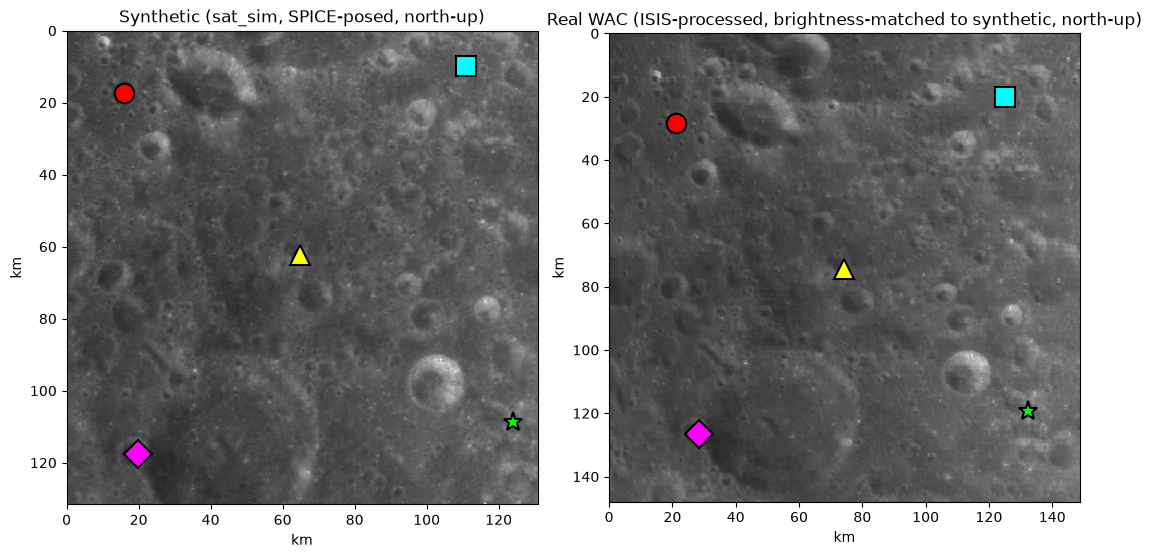

In [16]:
_ = plotting.plot_isis_comparison(
    camera, tie_point_results, entry.hillshade.raster_path, entry.crop.raster_path, rotations
)

## Phase 8: does the real-WAC-textured reprojection (`reproject`) check out?

A third `TrnTestImage` variant, distinct from both candidates above: `sat_sim` rendered through
the *exact same* `Camera` as Phase 5's `hillshade` (same pose, same corrected FOV -- see
`camera.solve_corrected_fov`'s docstring), but textured from the real WAC crop's own reflectance
(Phase 6's `cam2map` reprojection, `isis_wac.run_cam2map_for_crop`) instead of the Lunaserv/
Astropedia basemap. The user's own framing: "use `sat_sim` but for input data use the RDR of our
WAC crop essentially."

Because its geometry is byte-identical to `hillshade`'s (already validated against the basemap in
Phase 5), there's no need to re-run those basemap checks a third time here. The two questions
specific to `reproject` are instead: does the real crop's own footprint actually cover the
synthetic camera's FOV out to its corners -- checked directly below as a valid-pixel fraction, the
real-world question `docs/reproject-fov-investigation.md`'s FOV-correction work was ultimately in
service of -- and does texturing from the real WAC data, everything else held fixed, actually
produce something that looks like `hillshade` (below -- a direct pixel-for-pixel blink, no
reprojection needed, since the two share one pixel grid by construction).

Opt-in so far (`trn_dataset.PRODUCT_TYPES` still defaults to just `crop`+`hillshade`; Phase 2
above passes `product_types=PRODUCT_TYPES` explicitly to include it), and validated end-to-end on
this one entry, not yet at dataset scale across the whole manifest.

In [17]:
reproject_data = plotting.read_raster_band(entry.reproject.raster_path)
valid_frac = plotting.valid_pixel_mask(reproject_data).mean()
print(f"reproject valid pixels: {valid_frac:.1%}")

reproject valid pixels: 100.0%


### Comparing `hillshade` and `reproject` directly

Both are `sat_sim` renders through the exact same `Camera` -- same pose, same pixel grid, same
north-up rotation -- so unlike every other comparison in this notebook, this one needs no
`mapproject`/`cam2map` reprojection step at all: `plotting.plot_render_toggle` reads each render's
own raw pixels directly, brightness-matches them (a real ISIS-I/F-vs-synthetic-texture scale
difference, not just a stylistic choice -- see its docstring), and blinks between them the same
way `plot_overlay_toggle` does. If texture source were the *only* thing that mattered, the two
should blink as the same scene lit slightly differently; a real content/shape mismatch here would
point at something in `reproject`'s own texturing path, not at geometry (already ruled out by
construction).


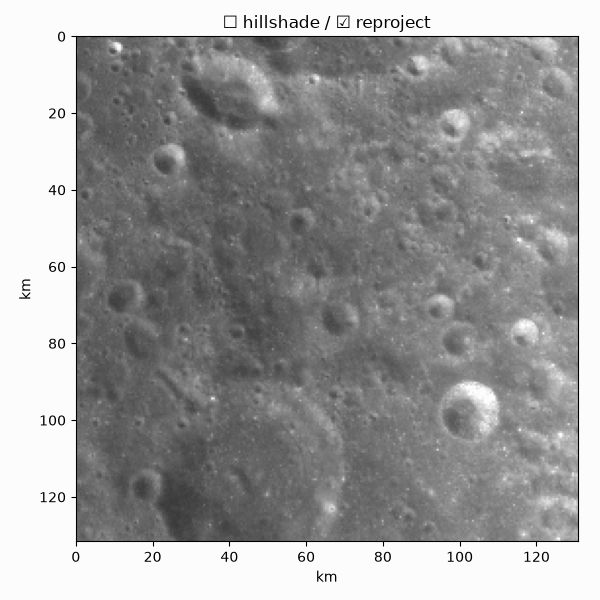

In [18]:
plotting.plot_render_toggle(
    entry.hillshade.raster_path,
    entry.reproject.raster_path,
    entry.rotations.k_synthetic,
    entry.hillshade.width_km,
    entry.hillshade.height_km,
    "hillshade",
    "reproject",
)

## Summary

- Rendered a real, illuminated LROC WAC EDR picked ahead of time by a catalog-driven, multi-orbit dataset search (`trntest.dataset.images_for_window`, via the PDS ODE REST API and SPICE-derived orbit/illumination geometry), then computed LRO's true position/orientation at that image's timestamp directly in the Moon's `MOON_ME` frame via `spiceypy`, using a minimal, selectively-cached SPICE kernel set (see `docs/caching.md`).
- Built a `.tsai` Pinhole camera from that pose and rendered a synthetic 256x256 image with ASP's `sat_sim`, fed by real DEM/imagery pulled live from Lunaserv WMS for the camera's own computed ground footprint (`trntest.TrnTestDataSet`/`TrnTestEntry`/`TrnTestImage` -- see `docs/dataset-plan.md`). Produced a CSM/"ISD" JSON sidecar for it (`cam_gen`), and cross-validated the whole pose pipeline: `cam_gen` independently recovered the same sub-spacecraft geodetic position from the `.tsai`'s raw ECEF pose that the original SPICE computation produced.
- Validated the synthetic render's geometry against the hillshade-based basemap two ways (Phase 5): a raw, north-up-rotated quality check (5A), and a true pixel-for-pixel geo-registered overlay via `mapproject` through the render's own CSM sidecar (5B).
- Processed the same real footprint's WAC EDR through ISIS3's own pipeline (`isis_wac.run_pipeline`) -- a genuine camera-model-based real-WAC product (EDR fetch through calibration and framelet interleaving) -- cropped it to the real footprint being compared (`isis_wac.crop_for_camera`), and validated that single crop's geometry against the same basemap the same two ways (Phase 6): a raw quality check (6A), and a `cam2map` overlay through ISIS's own native Pushframe camera model (6B) -- not ASP's `mapproject`/CSM, after finding a real bug in `usgscsm`'s `groundToImage` for Pushframe sensors.
- Compared the two TRN test image candidates directly against each other, with explicit tie points (Phase 7).
- Rendered a third candidate, `reproject`, through the exact same camera as the synthetic render but textured from the real WAC crop's own reflectance instead of the Lunaserv basemap, confirmed real coverage out to the FOV's corners, and directly blinked it against `hillshade` to isolate the effect of the texture source alone (Phase 8).